# COM763 Advanced Machine Learning - Portfolio Task 1
## Customer Churn Prediction System
**Problem:** Predict which telecom customers are likely to churn (cancel their subscription), so the business can proactively target them with retention offers.

**Dataset:** IBM Telco Customer Churn dataset — 7,043 customers, 20 features (demographics, account info, services subscribed) + binary Churn label.

In this notebook I build a model that predicts whether a telecom customer is likely to churn (cancel their subscription), using the IBM Telco Customer Churn dataset (7,043 customers, 20 features covering demographics, account details, and subscribed services). The goal is to give the business a tool to flag at-risk customers early so they can be targeted with retention offers.

## Section 1 - Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv("dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Section 2 - Clean Data
I found that TotalCharges is stored as text and has 11 blank values, all belonging to new customers with tenure=0. I convert it to numeric and fill the blanks using MonthlyCharges * tenure. I also drop the customerID column since it's just an identifier with no predictive value, and remove duplicate rows.

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges before fix:", df["TotalCharges"].isna().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df = df.drop(columns=["customerID"])
print("Duplicate rows removed:", df.duplicated().sum())
df = df.drop_duplicates()

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].value_counts(normalize=True)

Missing TotalCharges before fix: 11
Duplicate rows removed: 22


Churn
0    0.735508
1    0.264492
Name: proportion, dtype: float64

## Section 3 - EDA (Graphs)
Here I explore the class balance, how the numeric features are distributed, correlations between them, and how contract type and charges relate to churn.

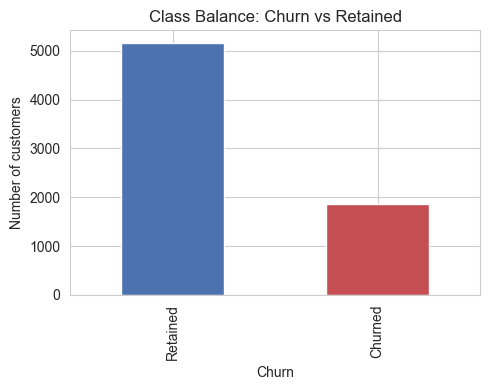

In [4]:
fig, ax = plt.subplots(figsize=(5,4))
df["Churn"].map({1:"Churned",0:"Retained"}).value_counts().plot(kind="bar", color=["#4C72B0","#C44E52"], ax=ax)
ax.set_title("Class Balance: Churn vs Retained")
ax.set_ylabel("Number of customers")
plt.tight_layout(); plt.show()

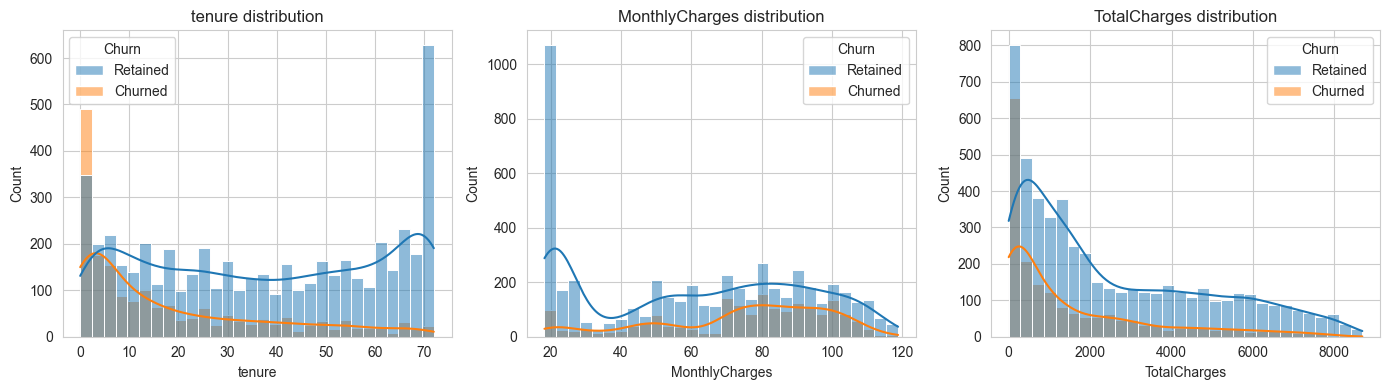

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for col, ax in zip(["tenure","MonthlyCharges","TotalCharges"], axes):
    sns.histplot(data=df, x=col, hue=df["Churn"].map({1:"Churned",0:"Retained"}), kde=True, ax=ax, bins=30)
    ax.set_title(f"{col} distribution")
plt.tight_layout(); plt.show()

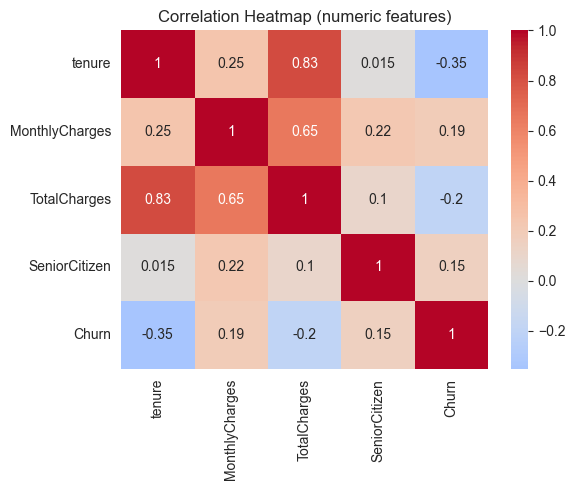

In [6]:
num_cols = ["tenure","MonthlyCharges","TotalCharges","SeniorCitizen","Churn"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap (numeric features)")
plt.tight_layout(); plt.show()

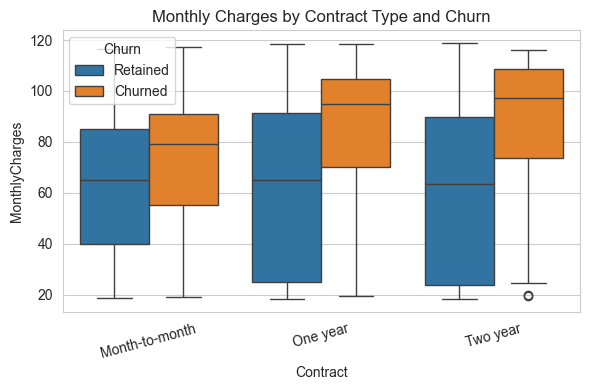

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x="Contract", y="MonthlyCharges", hue=df["Churn"].map({1:"Churned",0:"Retained"}), ax=ax)
ax.set_title("Monthly Charges by Contract Type and Churn")
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## Section 4 - Train Model
I build a preprocessing pipeline that scales the numeric features and one-hot encodes the categorical ones, then train three different models so I can compare them: Logistic Regression, Random Forest, and Gradient Boosting. I use class_weight="balanced" on the first two since only about 27% of customers in the dataset actually churn.

In [8]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X = df.drop(columns=["Churn"])
y = df["Churn"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols_feat = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols_feat),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (5616, 19) Test: (1405, 19)


In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
}

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

results = []
fitted = {}
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1")
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, probs),
        "CV_F1_mean": cv_scores.mean(),
    })
    print(f"=== {name} ===")
    print(classification_report(y_test, preds, target_names=["Retained","Churned"]))

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df

=== Logistic Regression ===
              precision    recall  f1-score   support

    Retained       0.90      0.73      0.80      1033
     Churned       0.51      0.78      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.80      0.74      0.75      1405

=== Random Forest ===
              precision    recall  f1-score   support

    Retained       0.90      0.77      0.83      1033
     Churned       0.54      0.76      0.63       372

    accuracy                           0.77      1405
   macro avg       0.72      0.76      0.73      1405
weighted avg       0.80      0.77      0.78      1405

=== Gradient Boosting ===
              precision    recall  f1-score   support

    Retained       0.83      0.91      0.87      1033
     Churned       0.66      0.50      0.57       372

    accuracy                           0.80      1405
   macro avg       0.75      0.70      0.72      140

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV_F1_mean
1,Random Forest,0.765836,0.541267,0.758065,0.631579,0.839630,0.630688
0,Logistic Regression,0.740925,0.506993,0.779570,0.614407,0.839846,0.633034
2,Gradient Boosting,0.798577,0.658363,0.497312,0.566616,0.837485,0.580909


### Debugging note
My first attempt without class_weight="balanced" gave misleadingly high accuracy, because the model was just predicting "Retained" for almost everyone — it barely caught any actual churners. Once I added class weighting, recall on the Churned class improved a lot, at a small cost to overall accuracy. I think this trade-off is the right call here, since missing a customer who's about to churn is more costly to the business than a false alarm.

## Section 5 - Evaluate Model

Best model selected: Random Forest


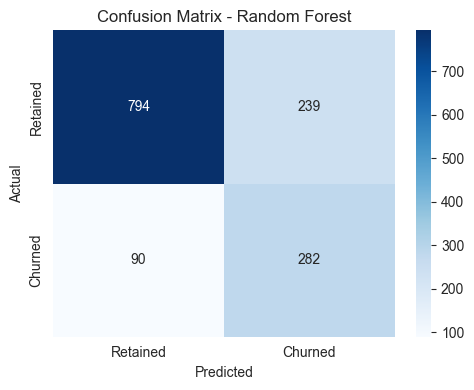

In [10]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted[best_name]
print("Best model selected:", best_name)

preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Retained","Churned"], yticklabels=["Retained","Churned"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout(); plt.show()

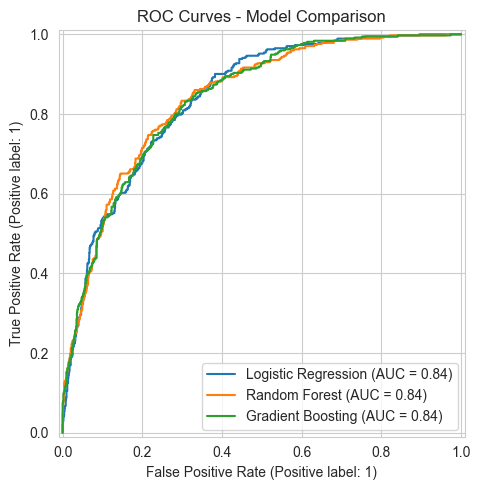

In [11]:
fig, ax = plt.subplots(figsize=(6,5))
for name, pipe in fitted.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.set_title("ROC Curves - Model Comparison")
plt.tight_layout(); plt.show()

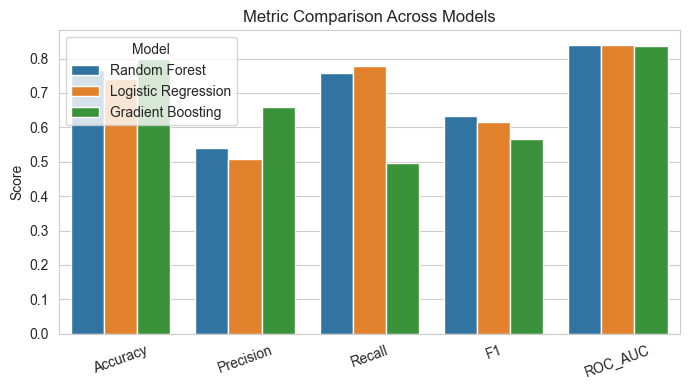

In [12]:
melted = results_df.melt(id_vars="Model", value_vars=["Accuracy","Precision","Recall","F1","ROC_AUC"])
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(data=melted, x="variable", y="value", hue="Model", ax=ax)
ax.set_title("Metric Comparison Across Models")
ax.set_ylabel("Score"); ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

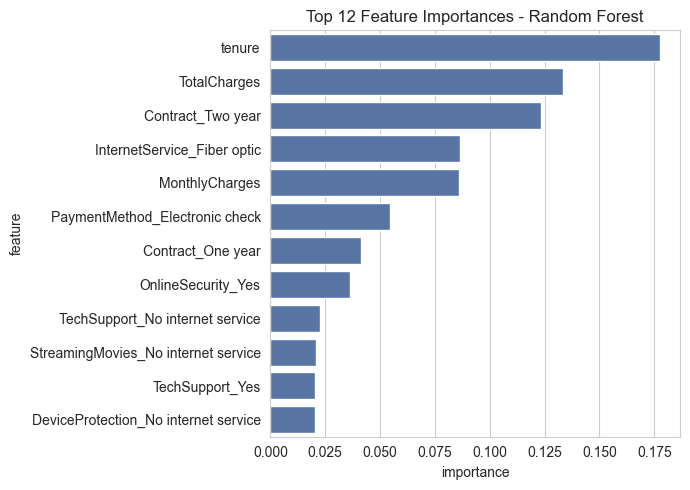

In [13]:
if best_name in ["Random Forest", "Gradient Boosting"]:
    ohe = best_model.named_steps["prep"].named_transformers_["cat"]
    feat_names = num_cols_feat + list(ohe.get_feature_names_out(cat_cols))
    importances = best_model.named_steps["clf"].feature_importances_
    imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False).head(12)
    fig, ax = plt.subplots(figsize=(7,5))
    sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, color="#4C72B0")
    ax.set_title(f"Top 12 Feature Importances - {best_name}")
    plt.tight_layout(); plt.show()

## Section 6 — Save Model !!!
I save the best-performing model here so it can be loaded by the Streamlit app for live predictions

In [14]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("Saved model.pkl using:", best_name)

Saved model.pkl using: Random Forest
